Random Shuffling Mean: 0.31447788417458267
Random Shuffling 95% Confidence Interval: (np.float64(0.3131913712135665), np.float64(0.31576439713559884))
0.6359143944404293
0.6158061649769099
0.6304471379031618
0.6473384302964538
0.6180170904411482
0.6359143944404293
0.6158061649769099
0.6304471379031618
0.6359143944404293
0.6158061649769099
0.6359143944404293
0.6158061649769099
0.6304471379031618
0.6473384302964538
0.6180170904411482
0.6359143944404293
0.6158061649769099
0.6304471379031618
0.6473384302964538
0.6180170904411482


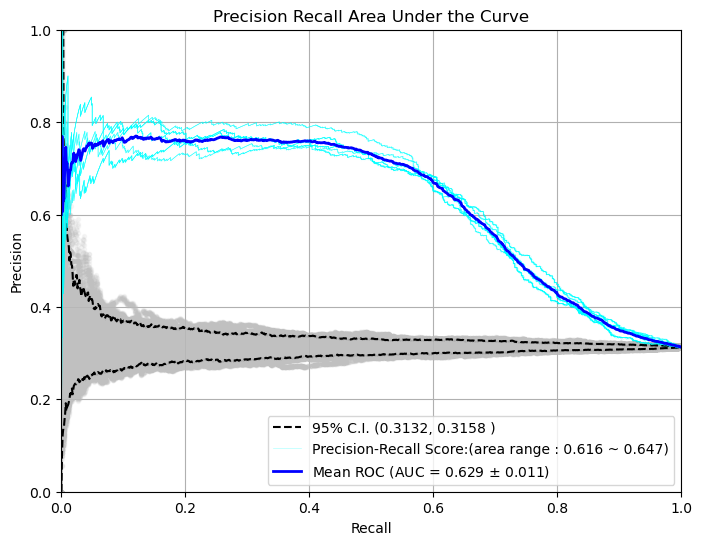

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import numpy as np
from sklearn.metrics import RocCurveDisplay, auc
from sklearn.metrics import precision_recall_curve
import scipy.stats as stats

list1=[]
list2=[]
count = 0
tpr_list = []
fpr_list = []
precision1s = []
random_aucs = []

# infile1 = open("tttt_random_label_file_200.txt","r")
# infile2 = open("tttt_random_pred_file_200.txt","r")

infile1 = open("tttt_random_label_200_add.txt","r")
infile2 = open("tttt_random_pred_200_add.txt","r")

recall_array = np.linspace(0, 1.0, 1000)

plt.figure(figsize=(8, 6))
for line1, line2 in zip(infile1, infile2):
    # print(line1[1:-2])
    line1_each = line1[1:-2].split(',')
    lines1 = []
    for f in line1_each:
        lines1.append(float(f))

    line2_each = line2[1:-2].split(',')
    lines2 = []
    for f in line2_each:
        lines2.append(float(f))


    # print ( len(lines1))
    count += 1
    plt.figure(1)
    
    precision1, recall1, thresholds = precision_recall_curve(lines1, lines2)
    auc_precision_recall = auc(recall1, precision1)
    precision1,  recall1 = precision1[::-1], recall1[::-1]
    random_aucs.append(auc_precision_recall)
    prec_array = np.interp(recall_array, recall1, precision1)

    precision1s.append(prec_array)
    # precision1s.append(precision1)
    # aucs.append(lr_auc)

    plt.plot(recall1, precision1, marker='.',label=None, color='silver', alpha=0.1)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.ylim(0.0,1.0)
    plt.xlim(0.0,1.0)

plt.figure(1)
pecent_95 = []
pecent_95_lower = []
precision1s = np.asarray(precision1s) 
for i in range(precision1s.shape[1]):
    p = np.percentile(precision1s[:,i], 97.5) 
    p_low = np.percentile(precision1s[:,i], 2.5) 
    pecent_95_lower.append(p_low)
    pecent_95.append(p)


precision1s[-1] = 1.0

def calculate_confidence_interval(data, confidence=0.95):
    # Convert data to a numpy array
    data = np.array(data)
    mean = np.mean(data)
    std = stats.sem(data)
    confidence_interval = stats.t.interval(confidence, len(data)-1, loc=mean, scale=std)
    return mean, confidence_interval
# Example usage
data = random_aucs  # Replace with your data list
mean, confidence_interval = calculate_confidence_interval(data)
print("Random Shuffling Mean:", mean)
print("Random Shuffling 95% Confidence Interval:", confidence_interval)



plt.plot(recall_array, pecent_95, marker='^', label=r"95%% C.I. (%0.4f, %0.4f )"% (confidence_interval[0], confidence_interval[1]),color='black',linestyle='dashed',markersize=0.01)
plt.plot(recall_array, pecent_95_lower,marker='^', color='black',linestyle='dashed',markersize=0.01)



infile1 = open("cana_label_file_200.txt","r")
infile2 = open("cana_pred_file_200.txt","r")

# infile1 = open("true_label_file_200.txt","r")
# infile2 = open("true_pred_file_200.txt","r")


true_precissions = []
lines1 = []
lines2 = []

aucs = []
count = 0
max_auc_precision_recall = -float('inf')
min_auc_precision_recall = float('inf')
for line1, line2 in zip(infile1, infile2):
    line1_each = line1[1:-2].split(',')
    lines1 = []
    for f in line1_each:
        lines1.append(float(f))

    line2_each = line2[1:-2].split(',')
    lines2 = []
    for f in line2_each:
        lines2.append(float(f))

    precision1, recall1, thresholds = precision_recall_curve(lines1, lines2)
    auc_precision_recall = auc(recall1, precision1)

    max_auc_precision_recall = max(max_auc_precision_recall, auc_precision_recall)
    min_auc_precision_recall = min(min_auc_precision_recall, auc_precision_recall)
    print(auc_precision_recall)
    aucs.append(auc_precision_recall)
    precision1,  recall1 = precision1[::-1], recall1[::-1]

    prec_array = np.interp(recall_array, recall1, precision1)
   
    true_precissions.append(prec_array)


    count += 1
    if count == 5:
        plt.plot(recall1, precision1, marker='.', label='Precision-Recall Score:(area range : %0.3f ~ %0.3f)'%(min_auc_precision_recall, max_auc_precision_recall),color='cyan', alpha=0.3,lw=0.5,markersize=0.01)
    else:
        plt.plot(recall1, precision1, marker='.', color='cyan', alpha=0.5, lw=0.4, markersize=0.01)


std_auc = np.std(aucs)
true_precissions = np.mean(true_precissions, axis=0)
# mean_tpr[-1] = 1.0
mean_auc = auc(recall_array, true_precissions) 


plt.plot(recall_array, true_precissions, marker='.', label= r"Mean ROC (AUC = %0.3f $\pm$ %0.3f)" % (mean_auc, std_auc),color='blue',lw=2,markersize=0.01)


baseline = sum(lines1) / len(lines1)
# plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='k',label='Baseline: {:.3f}'.format(no_skill))
# plt.plot([0, 1], [baseline, baseline], 'k-', linewidth=0.5)
plt.grid(True)
plt.legend(loc="lower right")
plt.title("Precision Recall Area Under the Curve")
plt.show()
# plt.savefig("aaaaaa_prauc_200.png")
# plt.savefig("aaaaaa_prauc_200_add.png", dpi=1200)

# 
# print(count)